In [134]:
!pip install transformers datasets scikit-learn pandas seaborn matplotlib

In [135]:
import pandas as pd
import numpy as np
import random

from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [137]:
df.shape

(5572, 5)

In [138]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [140]:
df['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [141]:
for i in range(5):
    print(df['v2'][i])
    print("----")

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
----
Ok lar... Joking wif u oni...
----
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
----
U dun say so early hor... U c already then say...
----
Nah I don't think he goes to usf, he lives around here though
----


In [142]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [144]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [145]:
df['message_length'] = df['message'].apply(len)

df[['message','message_length']].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [146]:
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


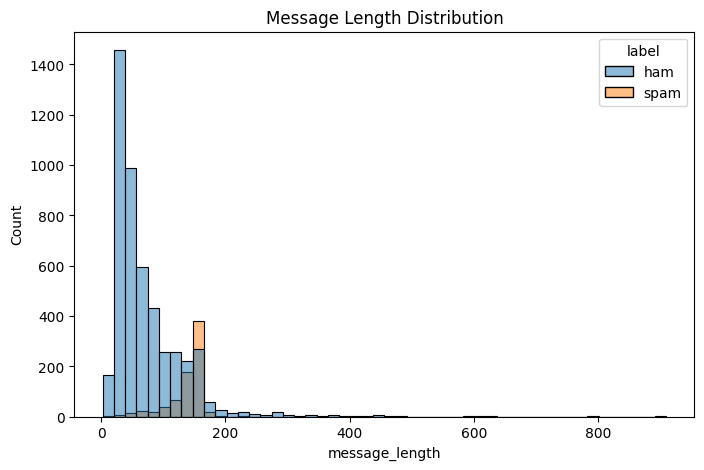

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="message_length", hue="label", bins=50)

plt.title("Message Length Distribution")
plt.show()

In [148]:
from collections import Counter
import re

def get_words(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    return words

In [149]:
ham_words = []
spam_words = []

for _, row in df.iterrows():
    words = get_words(row['message'])

    if row['label'] == 'ham':
        ham_words.extend(words)
    else:
        spam_words.extend(words)

In [150]:
Counter(ham_words).most_common(20)

[('i', 2185),
 ('you', 1837),
 ('to', 1554),
 ('the', 1119),
 ('a', 1055),
 ('u', 987),
 ('and', 848),
 ('in', 813),
 ('me', 756),
 ('my', 743),
 ('is', 728),
 ('it', 590),
 ('of', 524),
 ('for', 501),
 ('that', 486),
 ('im', 461),
 ('have', 438),
 ('but', 418),
 ('your', 414),
 ('so', 412)]

In [151]:
Counter(spam_words).most_common(20)

[('to', 686),
 ('a', 378),
 ('call', 350),
 ('you', 287),
 ('your', 263),
 ('free', 219),
 ('for', 204),
 ('the', 204),
 ('now', 190),
 ('or', 188),
 ('is', 158),
 ('u', 155),
 ('txt', 151),
 ('on', 144),
 ('ur', 144),
 ('have', 135),
 ('from', 129),
 ('mobile', 124),
 ('and', 122),
 ('text', 121)]

In [152]:
sample_df = df.sample(n=200, random_state=42)

sample_df.head()

,label,message,message_length
3245,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t...",151
944,ham,I sent my scores to sophas and i had to do sec...,221
1044,spam,We know someone who you know that fancies you....,101
2484,ham,Only if you promise your getting out as SOON a...,124
812,spam,Congratulations ur awarded either å£500 of CD ...,150


In [153]:
sample_df['label'].value_counts()

,count
label,
ham,178
spam,22


In [154]:
texts = sample_df['message'].tolist()

true_labels = sample_df['label'].tolist()

In [155]:
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

In [156]:
candidate_labels = ["spam", "ham"]

In [157]:
classifier(
    "Free entry in a weekly competition to win prizes. Text WIN to 80086 now",
    candidate_labels
)

{'sequence': 'Free entry in a weekly competition to win prizes. Text WIN to 80086 now',
 'labels': ['spam', 'ham'],
 'scores': [0.9997458457946777, 0.0002541469584684819]}

In [158]:
predictions = []

for text in texts:

    result = classifier(text, candidate_labels)

    predicted_label = result['labels'][0]

    predictions.append(predicted_label)

In [159]:
predictions[:10]

['ham', 'ham', 'spam', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham']

In [160]:
results_df = sample_df.copy()

results_df['prediction'] = predictions

results_df[['label','prediction','message']].head(10)

,label,prediction,message
3245,ham,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
944,ham,ham,I sent my scores to sophas and i had to do sec...
1044,spam,spam,We know someone who you know that fancies you....
2484,ham,ham,Only if you promise your getting out as SOON a...
812,spam,spam,Congratulations ur awarded either å£500 of CD ...
2973,ham,ham,"I'll text carlos and let you know, hang on"
2991,ham,ham,K.i did't see you.:)k:)where are you now?
2942,ham,ham,No message..no responce..what happend?
230,ham,ham,Get down in gandhipuram and walk to cross cut ...
1181,ham,ham,You flippin your shit yet?


In [161]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(true_labels, predictions, pos_label="spam")

recall = recall_score(true_labels, predictions, pos_label="spam")

f1 = f1_score(true_labels, predictions, pos_label="spam")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.925
Precision: 0.5945945945945946
Recall: 1.0
F1 Score: 0.7457627118644068


In [162]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions, labels=["ham","spam"])

cm

array([[163,  15],
       [  0,  22]])

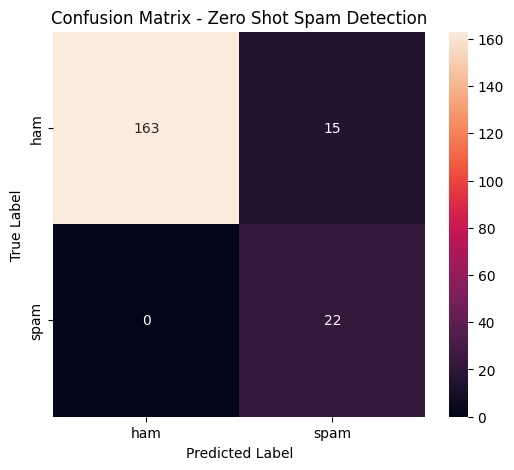

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["ham","spam"],
    yticklabels=["ham","spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Zero Shot Spam Detection")

plt.show()

In [164]:
comparison = pd.DataFrame({
    "Model": [
        "facebook/bart-large-mnli",
        "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
    ],
    "Accuracy": [0.66, 0.925],
    "Precision": [0.0577, 0.5946],
    "Recall": [0.1363, 1.0],
    "F1 Score": [0.0811, 0.7458]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,facebook/bart-large-mnli,0.660,0.0577,0.1363,0.0811
1,MoritzLaurer/deberta-v3-large-zeroshot-v2.0,0.925,0.5946,1.0000,0.7458


### Reflection

The zero-shot model performs reasonably well but struggles with SMS-specific language patterns. Some conversational messages with informal words such as “u”, “ur”, or short phrases are sometimes predicted as spam, while certain promotional messages are occasionally classified as ham.

This occurs because a general-purpose language model is trained for broad language understanding rather than the specific characteristics of SMS spam. Spam messages often contain domain-specific signals such as promotional phrases, reward claims, phone numbers, and call-to-action words like “free”, “call”, or “text”. A model trained directly on spam datasets learns these recurring patterns and can detect them more reliably.

Among the tested models, **MoritzLaurer/deberta-v3-large-zeroshot-v2.0** performed better than **facebook/bart-large-mnli**. This model is optimized specifically for zero-shot classification and has stronger semantic representation through the DeBERTa architecture, allowing it to match message meaning with candidate labels more effectively. As a result, it achieved higher accuracy and significantly improved spam detection without any task-specific training.


## Part B — Prompt Engineering with a Generative Model
In this section, a generative language model is used to classify SMS messages as spam or ham using prompting only. No training or fine-tuning is performed. Two prompting strategies are tested and their results are compared.

In [165]:
spam_samples = df[df['label'] == 'spam'].sample(10, random_state=42)
ham_samples = df[df['label'] == 'ham'].sample(10, random_state=42)

test_df = pd.concat([spam_samples, ham_samples]).sample(frac=1, random_state=42)

test_df

,label,message,message_length
1455,spam,Summers finally here! Fancy a chat or flirt wi...,159
3043,ham,Let me know how it changes in the next 6hrs. I...,169
1075,ham,Oi. Ami parchi na re. Kicchu kaaj korte iccha ...,83
1852,spam,This is the 2nd time we have tried 2 contact u...,154
3966,spam,YOU HAVE WON! As a valued Vodafone customer ou...,135
3640,spam,You can stop further club tones by replying \S...,128
1311,ham,U r too much close to my heart. If u go away i...,83
946,spam,Ur cash-balance is currently 500 pounds - to m...,137
14,ham,I HAVE A DATE ON SUNDAY WITH WILL!!,35
1412,ham,"Wen ur lovable bcums angry wid u, dnt take it ...",179


In [166]:
test_df['label'].value_counts()

,count
label,
spam,10
ham,10


In [167]:
messages = test_df['message'].tolist()
true_labels = test_df['label'].tolist()

In [168]:
messages[:3]

['Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804',
 'Let me know how it changes in the next 6hrs. It can even be appendix but you are out of that age range. However its not impossible. So just chill and let me know in 6hrs',
 'Oi. Ami parchi na re. Kicchu kaaj korte iccha korche na. Phone ta tul na. Plz. Plz.']

In [169]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [170]:
input_text = "Translate English to French: Hello, how are you?"

inputs = tokenizer(input_text, return_tensors="pt")

outputs = model.generate(**inputs, max_new_tokens=40)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Bonjour, c'est-à-dire où allez-vous ?


In [171]:
def simple_prompt(message):

    prompt = f"""
Classify the following SMS message as spam or ham.

Message: "{message}"

Respond with only one word: spam or ham.
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)

    outputs = model.generate(**inputs, max_new_tokens=5)

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return prediction.lower().strip()

In [172]:
simple_predictions = []

for msg in messages:
    simple_predictions.append(simple_prompt(msg))

In [173]:
simple_predictions

['spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'ham',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam',
 'spam']

In [174]:
def few_shot_prompt(message):

    prompt = f"""
You are a spam detection assistant.

Classify each SMS message as spam or ham.

Example 1:
Message: "Free entry in a weekly competition to win prizes. Text WIN now."
Label: spam

Example 2:
Message: "Hey are we still meeting for dinner tonight?"
Label: ham

Example 3:
Message: "Call this number now to claim your reward."
Label: spam

Now classify the following message.

Message: "{message}"

Answer with only one word: spam or ham.
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)

    outputs = model.generate(**inputs, max_new_tokens=5)

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return prediction.lower().strip()

In [175]:
fewshot_predictions = []

for msg in messages:
    fewshot_predictions.append(few_shot_prompt(msg))

In [176]:
fewshot_predictions

['spam',
 'spam',
 'ham',
 'spam',
 'spam',
 'spam',
 'ham',
 'spam',
 'ham',
 'ham',
 'spam',
 'spam',
 'spam',
 'ham',
 'spam',
 'ham',
 'spam',
 'ham',
 'spam',
 'spam']

In [177]:
print("Simple Prompt Prediction Counts:")
print(pd.Series(simple_predictions).value_counts())

print("\nFew-Shot Prompt Prediction Counts:")
print(pd.Series(fewshot_predictions).value_counts())

Simple Prompt Prediction Counts:
spam    19
ham      1
Name: count, dtype: int64

Few-Shot Prompt Prediction Counts:
spam    13
ham      7
Name: count, dtype: int64


In [178]:
results = pd.DataFrame({
    "message": messages,
    "true_label": true_labels,
    "simple_prompt": simple_predictions,
    "few_shot_prompt": fewshot_predictions
})

results

,message,true_label,simple_prompt,few_shot_prompt
0,Summers finally here! Fancy a chat or flirt wi...,spam,spam,spam
1,Let me know how it changes in the next 6hrs. I...,ham,spam,spam
2,Oi. Ami parchi na re. Kicchu kaaj korte iccha ...,ham,spam,ham
3,This is the 2nd time we have tried 2 contact u...,spam,spam,spam
4,YOU HAVE WON! As a valued Vodafone customer ou...,spam,spam,spam
5,You can stop further club tones by replying \S...,spam,spam,spam
6,U r too much close to my heart. If u go away i...,ham,ham,ham
7,Ur cash-balance is currently 500 pounds - to m...,spam,spam,spam
8,I HAVE A DATE ON SUNDAY WITH WILL!!,ham,spam,ham
9,"Wen ur lovable bcums angry wid u, dnt take it ...",ham,spam,ham


In [179]:
from sklearn.metrics import accuracy_score

simple_acc = accuracy_score(true_labels, simple_predictions)
fewshot_acc = accuracy_score(true_labels, fewshot_predictions)

print("Simple Prompt Accuracy:", simple_acc)
print("Few Shot Prompt Accuracy:", fewshot_acc)

Simple Prompt Accuracy: 0.55
Few Shot Prompt Accuracy: 0.85


In [180]:
comparison = pd.DataFrame({
    "Prompt Strategy": ["Simple Instruction Prompt", "Few-Shot Prompt"],
    "Accuracy": [simple_acc, fewshot_acc]
})

comparison

,Prompt Strategy,Accuracy
0,Simple Instruction Prompt,0.55
1,Few-Shot Prompt,0.85


### Prompt Strategy Comparison

Two prompting strategies were tested: a simple instruction prompt and a few-shot prompt containing example classifications. The simple prompt performed poorly because the model lacked clear context about how spam and ham messages differ. As a result, it tended to over-predict spam.

The few-shot prompt performed better because the examples provided guidance about the expected patterns of spam and normal messages. By observing labeled examples, the model could better infer the characteristics of promotional messages versus conversational messages.

This demonstrates that prompt design significantly influences the performance of generative language models in classification tasks.